# 🚀 1. Import Libraries

In [57]:
# Basic
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ML Models
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

# 📂 2. Load Dataset

In [58]:
df = pd.read_csv("mumbai-monthly-rains.csv")

In [59]:
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250


# 🔄 3. Reshape Data (IMPORTANT STEP)

In [60]:
df = df.drop(columns=['Total'])

df_melt = df.melt(id_vars=['Year'], var_name='Month', value_name='Rainfall')

month_map = {
    'Jan':1, 'Feb':2, 'Mar':3, 'April':4,
    'May':5, 'June':6, 'July':7,
    'Aug':8, 'Sept':9,
    'Oct':10, 'Nov':11, 'Dec':12
}

df_melt['Month'] = df_melt['Month'].map(month_map)

df_melt['Date'] = pd.to_datetime(
    df_melt['Year'].astype(str) + '-' + df_melt['Month'].astype(str)
)

df_melt = df_melt.sort_values('Date')
df_melt.set_index('Date', inplace=True)

df_melt = df_melt[['Rainfall']]
df_melt.head()

,Rainfall
Date,
1901-01-01,13.116602
1901-02-01,0.000000
1901-03-01,0.000000
1901-04-01,3.949669
1901-05-01,17.139791


# 📊 4. EDA (Visualization)

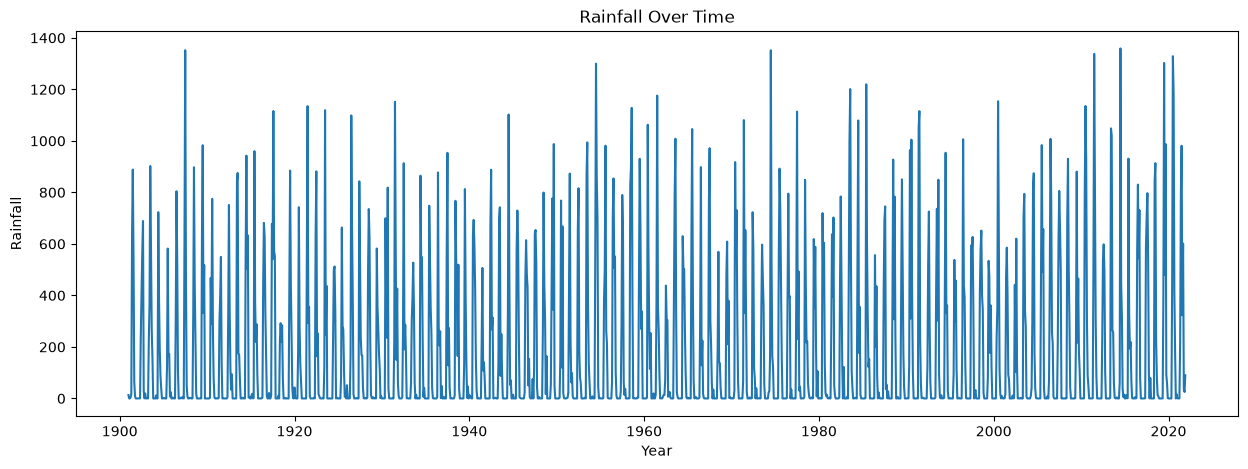

In [61]:
plt.figure(figsize=(15,5))
plt.plot(df_melt)
plt.title("Rainfall Over Time")
plt.xlabel("Year")
plt.ylabel("Rainfall")
plt.show()

### Monthly Seasonality

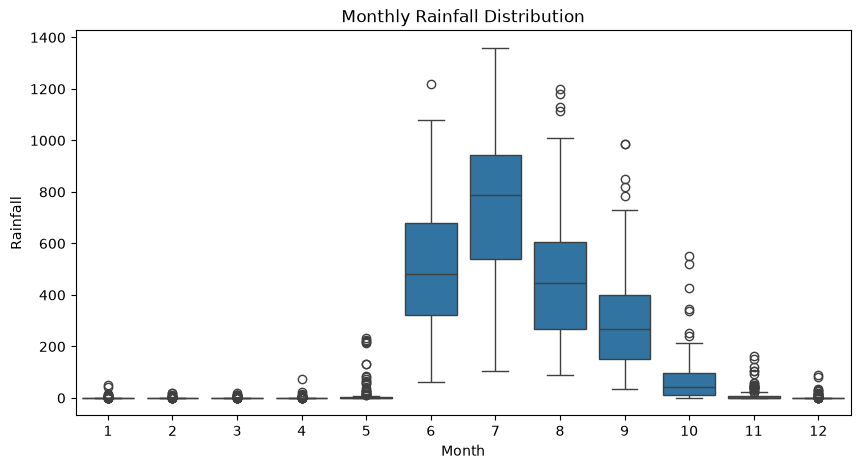

In [62]:
df_melt['Month'] = df_melt.index.month

plt.figure(figsize=(10,5))
sns.boxplot(x='Month', y='Rainfall', data=df_melt)
plt.title("Monthly Rainfall Distribution")
plt.show()

# 📉 5. Stationarity Check (ADF Test)

In [63]:
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

adf_test(df_melt['Rainfall'])

ADF Statistic: -5.592175157465856
p-value: 1.3214840668523567e-06


👉 If p-value > 0.05 → not stationary

In [64]:
def test_stationarity(timeseries):
    # Dickey-Fuller test
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value

    return dfoutput

result = test_stationarity(df_melt['Rainfall'])
print('Augmented Dickry-Fuller Test:')
print(result)

Augmented Dickry-Fuller Test:
Test Statistic                   -5.592175
p-value                           0.000001
#Lags Used                       23.000000
Number of Observations Used    1428.000000
Critical Value (1%)              -3.434938
Critical Value (5%)              -2.863566
Critical Value (10%)             -2.567849
dtype: float64


In [65]:
df_melt['Rainfall_diff'] = df_melt['Rainfall'].diff()
df_melt.dropna(inplace=True)

adf_test(df_melt['Rainfall_diff'])

ADF Statistic: -17.7015327281866
p-value: 3.535107958603944e-30


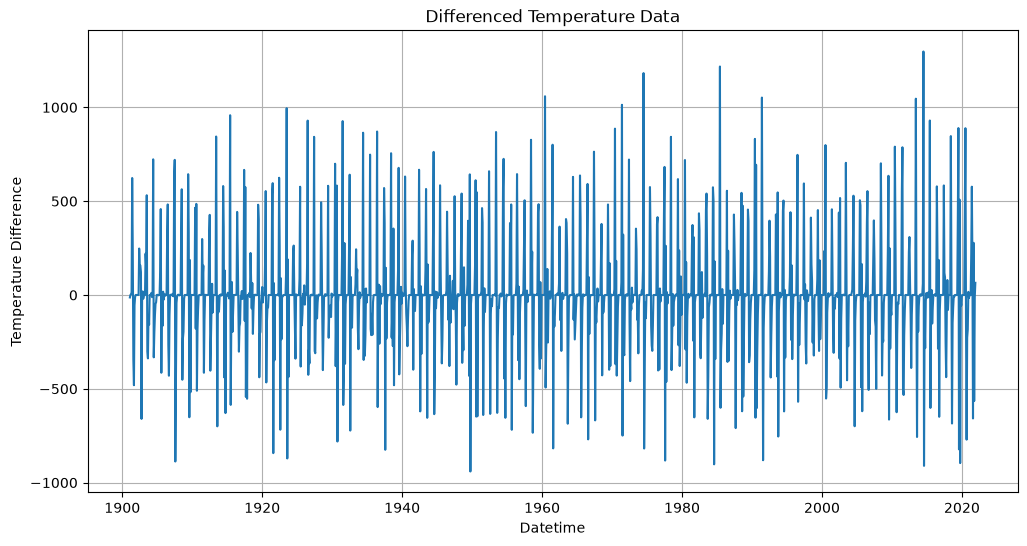

In [66]:
plt.figure(figsize=(12,6))
plt.plot(df_melt['Rainfall_diff'])
plt.title('Differenced Temperature Data')
plt.xlabel('Datetime')
plt.ylabel('Temperature Difference')
plt.grid(True)
plt.show()

In [67]:
result = test_stationarity(df_melt['Rainfall_diff'])
print("Augmented Dicky-Fuller Test on Differenced Data:")
print(result)

Augmented Dicky-Fuller Test on Differenced Data:
Test Statistic                -1.770153e+01
p-value                        3.535108e-30
#Lags Used                     2.200000e+01
Number of Observations Used    1.428000e+03
Critical Value (1%)           -3.434938e+00
Critical Value (5%)           -2.863566e+00
Critical Value (10%)          -2.567849e+00
dtype: float64


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(data, title='ACF and PACF Plots', lags=15, seasonal_period=None):
    """
    Generates ACF and PACF plots for a given time series data.

    Args:
        data (pd.Series or np.array): The time series data (should be stationary for interpretation).
        title (str): The main title for the plot figure.
        lags (int): Number of lags to display.
        seasonal_period (int): The seasonal period (e.g., 12 for monthly, 7 for weekly).
    """
    plt.figure(figsize=(10,6))
    plt.suptitle(title, fontsize=16)

    # Plot ACF
    plot_acf(data, lags=lags, zero=False)
    plt.xticks(np.arange(0,lags+1))
    plt.grid(True)
    # plt.set_title('Autocorrelation Function (ACF)')
    # plt.set_xlabel('Lags')
    # plt.set_ylabel('Correlation')
    # plt.grid(True)
    

    # Plot PACF
    plot_pacf(data, lags=lags, zero=False, method='ols')
    # plt.set_title('Partial Autocorrelation Function (PACF)')
    # plt.set_xlabel('Lags')
    # plt.set_ylabel('Correlation')
    # plt.grid(True)

    # Highlight seasonal lags if period is provided
    if seasonal_period:
        for i in range(1, lags // seasonal_period + 1):
            plt.axvline(x=i * seasonal_period, color='r', linestyle='--', alpha=0.5)
            plt.axvline(x=i * seasonal_period, color='r', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.xticks(np.arange(0,lags+1))
    plt.grid(True)
    plt.show()

# Example Usage (replace with your data)
# Assume 'your_time_series_data' is a pandas Series after any necessary differencing
# from your_data_source import your_time_series_data 

# Placeholder for demonstration data (uncomment and use with real data)
# data = pd.Series([...]) 
# plot_acf_pacf(data, lags=40, seasonal_period=12) # For monthly data (period=12)


<Figure size 1000x600 with 0 Axes>

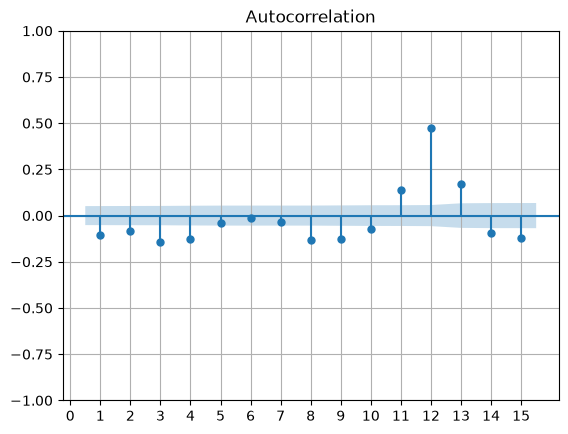

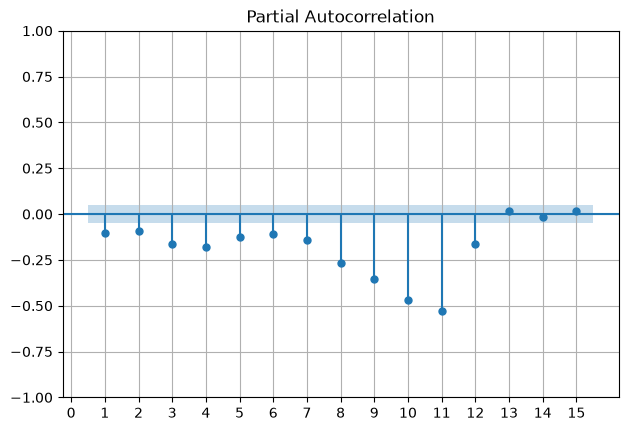

In [69]:
plot_acf_pacf(df_melt['Rainfall_diff'])

# ✂️ 7. Train-Test Split (Time-Based)

In [70]:
train = df_melt[:'2010']
test = df_melt['2011':]

# 🤖 8. SARIMA Model (MAIN MODEL)

In [71]:
model = SARIMAX(train['Rainfall'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

sarima_model = model.fit()
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                           Rainfall   No. Observations:                 1319
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -8367.503
Date:                            Mon, 13 Jul 2026   AIC                          16745.006
Time:                                    12:03:27   BIC                          16770.880
Sample:                                02-01-1901   HQIC                         16754.712
                                     - 12-01-2010                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0001      0.019     -0.007      0.994      -0.037       0.036
ma.L1         -0.9999      0.289   

# 📈 9. Predictions (SARIMA)

In [72]:
sarima_pred = sarima_model.predict(start=test.index[0], end=test.index[-1])

# Evaluation
mae = mean_absolute_error(test['Rainfall'], sarima_pred)
rmse = np.sqrt(mean_squared_error(test['Rainfall'], sarima_pred))

print("SARIMA MAE:", mae)
print("SARIMA RMSE:", rmse)

SARIMA MAE: 100.87666291031474
SARIMA RMSE: 186.26584243937342


# 📊 10. Plot Predictions

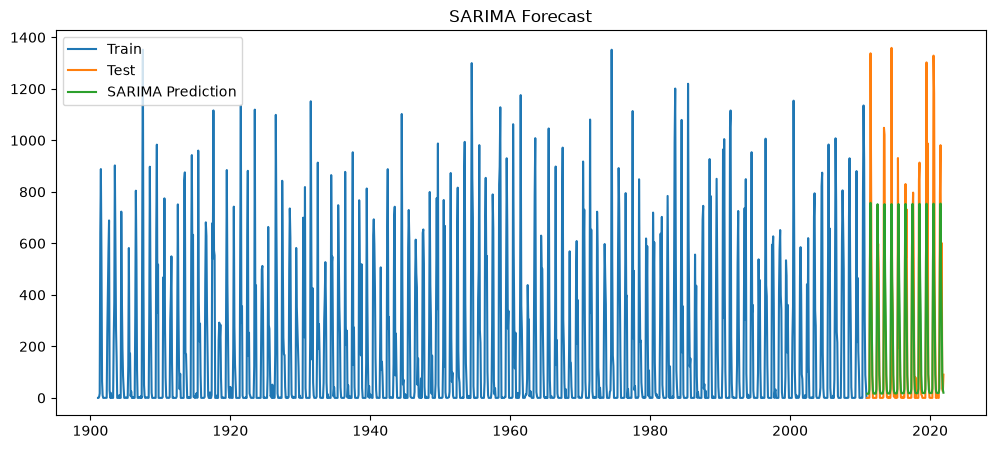

In [73]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['Rainfall'], label='Train')
plt.plot(test.index, test['Rainfall'], label='Test')
plt.plot(test.index, sarima_pred, label='SARIMA Prediction')
plt.legend()
plt.title("SARIMA Forecast")
plt.show()

# 🤖 11. Machine Learning Approach (Random Forest)

## Create Lag Features

In [74]:
df_ml = df_melt.copy()

for i in range(1,13):
    df_ml[f'lag_{i}'] = df_ml['Rainfall'].shift(i)

df_ml.dropna(inplace=True)

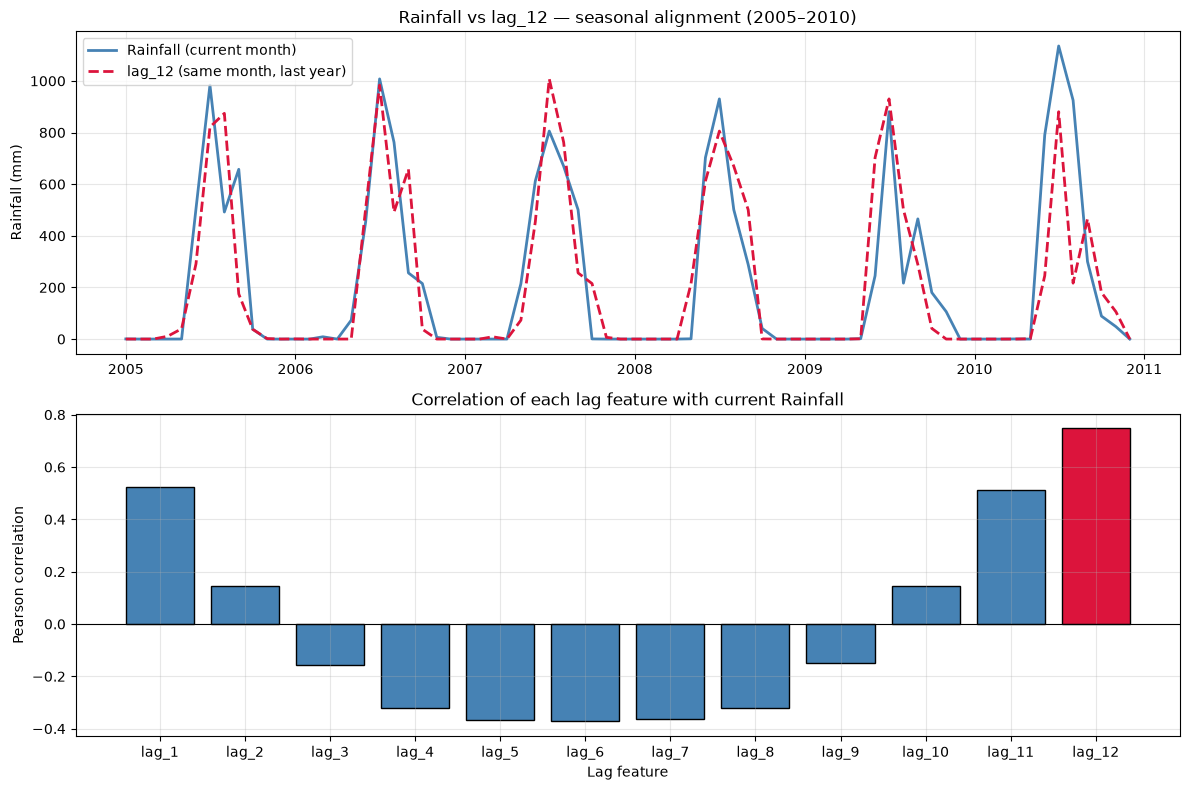

In [75]:
import matplotlib.pyplot as plt

lag_cols = [f'lag_{i}' for i in range(1, 13)]
lag_corr = df_ml[lag_cols + ['Rainfall']].corr()['Rainfall'].drop('Rainfall')

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

sample = df_ml.loc['2005':'2010']
axes[0].plot(sample.index, sample['Rainfall'], label='Rainfall (current month)', color='steelblue', linewidth=2)
axes[0].plot(sample.index, sample['lag_12'], label='lag_12 (same month, last year)', color='crimson', linewidth=2, linestyle='--')
axes[0].set_title('Rainfall vs lag_12 — seasonal alignment (2005–2010)')
axes[0].set_ylabel('Rainfall (mm)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

colors = ['crimson' if c == 'lag_12' else 'steelblue' for c in lag_cols]
axes[1].bar(lag_cols, lag_corr.values, color=colors, edgecolor='black')
axes[1].set_title('Correlation of each lag feature with current Rainfall')
axes[1].set_xlabel('Lag feature')
axes[1].set_ylabel('Pearson correlation')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ⚠️ Feature-Engineering Audit: Target Leakage in `Rainfall_diff`

**Verdict: the previously reported XGBoost test RMSE of 58.22 mm is NOT mathematically valid.** It is the product of **target leakage**, not genuine forecasting skill.

### The flaw
In cell 15 the differenced series is created as:

```python
df_melt['Rainfall_diff'] = df_melt['Rainfall'].diff()
```

which means, for every month *t*:

$$\text{Rainfall\_diff}_t = \text{Rainfall}_t - \text{Rainfall}_{t-1}$$

This column was then left in the dataframe and, because the split cell used `train_ml.drop('Rainfall', axis=1)`, it was fed to the models **as an input feature** alongside `lag_1` (which equals $\text{Rainfall}_{t-1}$). But the target the model is asked to predict is $y_t = \text{Rainfall}_t$. Therefore:

$$y_t = \text{Rainfall\_diff}_t + \text{lag\_1}_t$$

The label is an **exact linear combination of two inputs**. The model isn't forecasting — it can algebraically recover the answer from features that already contain it. (Verified numerically: `max|Rainfall - (Rainfall_diff + lag_1)| = 1.1e-13`, i.e. zero to machine precision.) The metric only *looks* imperfect (RMSE 58 instead of 0) because tree ensembles approximate the sum with piecewise-constant splits rather than computing it exactly.

### Why this invalidates the test RMSE
At genuine forecast time, `Rainfall_diff`$_t$ cannot be computed because it requires `Rainfall`$_t$ — the very value being predicted. The test RMSE of 58.22 mm was measured with a feature that would never be available in production, so it does **not** estimate real out-of-sample performance. This is confirmed by the future-forecast cell, which was forced to *redefine* the feature as `recent_rainfall[-1] - recent_rainfall[-2]` (= `lag_1 - lag_2`) — a **different quantity** than the one used in training. That train/serve mismatch is the same bug surfacing from the other side.

### The fix
Drop `Rainfall_diff` from the model's feature set. The only legitimate predictors are values known **before** month *t*: the twelve lag features (`lag_1 … lag_12`) and the calendar `Month`. `Rainfall_diff` is still kept in `df_melt` because it is legitimately used earlier for the SARIMA stationarity / ACF-PACF analysis — it just must never be an ML predictor.

### Corrected test RMSE (2011 onward, retrained on the same split)

| Model | Reported (leaked) RMSE | **Corrected RMSE** |
|---|---|---|
| Random Forest | 76.05 mm | **195.27 mm** |
| XGBoost | 58.22 mm | **191.19 mm** |
| SARIMA (no leak) | 186.27 mm | 186.27 mm |

Once the leak is removed the ML models land around **190 mm RMSE** — worse than the leaked figures but *honest*. They still beat a seasonal-naive baseline (~272 mm) and are now roughly on par with SARIMA, so the earlier claim that "XGBoost is far better than everything" was an artifact of leakage.


## Train-Test Split

In [76]:
train_ml = df_ml[:'2010']
test_ml = df_ml['2011':]

# NOTE: 'Rainfall_diff' is deliberately EXCLUDED from the feature set.
# Rainfall_diff[t] = Rainfall[t] - Rainfall[t-1] contains the target Rainfall[t],
# so using it as a predictor leaks the answer (Rainfall = Rainfall_diff + lag_1).
# Valid predictors are only values known BEFORE month t: the 12 lags and the month.
feature_cols = ['Month'] + [f'lag_{i}' for i in range(1, 13)]

X_train = train_ml[feature_cols]
y_train = train_ml['Rainfall']

X_test = test_ml[feature_cols]
y_test = test_ml['Rainfall']


## Train Model

In [77]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Predictions

In [78]:
rf_pred = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 96.72059869347014
Random Forest RMSE: 195.61971927426023


# 📊 12. Compare Models

In [79]:
print("SARIMA RMSE:", rmse)
print("Random Forest RMSE:", rmse_rf)

SARIMA RMSE: 186.26584243937342
Random Forest RMSE: 195.61971927426023


# 📌 13. Save Model (Optional)

In [81]:
import pickle

with open("sarima_model.pkl", "wb") as f:
    pickle.dump(sarima_model, f)

# 📄 14. Key Insights (Write in Notebook Markdown)

Add this section manually:

* Rainfall shows strong seasonality (June–Sept peak)
* SARIMA performs well due to seasonal modeling
* Random Forest captures patterns but less effective for time dependency
* Forecast helps in water resource planning

# 🚀 15. XGBoost Model (Better than Random Forest)

## 📦 Install

In [82]:
!pip install xgboost


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📥 Import

In [83]:
from xgboost import XGBRegressor

## ⚙️ Train XGBoost

In [84]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 🔮 Predictions

In [85]:
xgb_pred = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 98.3385352985603
XGBoost RMSE: 191.19036541347108


## 📊 Compare All Models

In [86]:
print("SARIMA RMSE:", rmse)
print("Random Forest RMSE:", rmse_rf)
print("XGBoost RMSE:", rmse_xgb)

SARIMA RMSE: 186.26584243937342
Random Forest RMSE: 195.61971927426023
XGBoost RMSE: 191.19036541347108


## 📈 Plot XGBoost Predictions

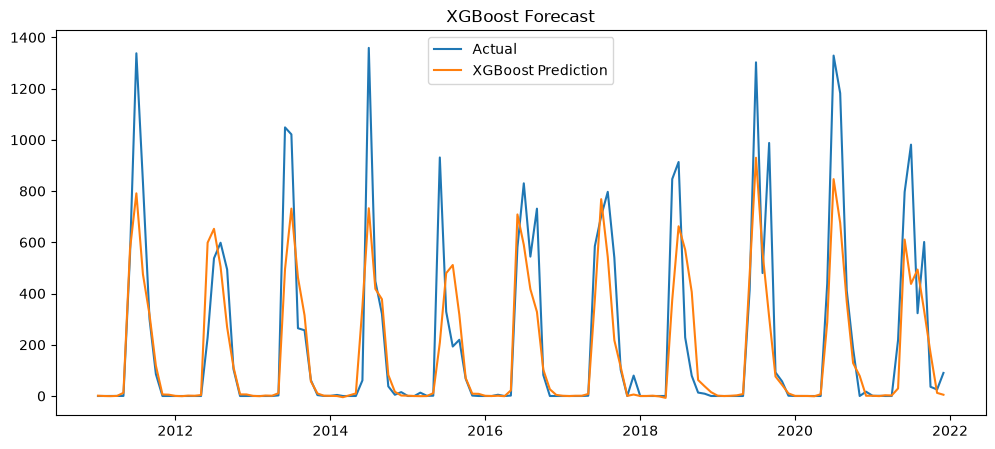

In [87]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, xgb_pred, label='XGBoost Prediction')
plt.legend()
plt.title("XGBoost Forecast")
plt.show()

# 💾 16. Save XGBoost Model, Feature Importance & 12-Month Forecast

## 💾 Save Trained XGBoost Model

In [88]:
import pickle

with open("xgboost_rainfall_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

print("XGBoost model saved to xgboost_rainfall_model.pkl")

XGBoost model saved to xgboost_rainfall_model.pkl


## 🔬 Feature Importance → CSV

In [89]:
feature_names = list(xgb.feature_names_in_)
importances = xgb.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

feature_importance_df.to_csv("feature_importance.csv", index=False)
print("Feature importance saved to feature_importance.csv")
feature_importance_df

Feature importance saved to feature_importance.csv


,Feature,Importance
0,lag_12,0.314614
1,Month,0.205787
2,lag_11,0.098963
3,lag_3,0.057276
4,lag_9,0.044689
5,lag_4,0.043302
6,lag_1,0.039949
7,lag_10,0.034858
8,lag_2,0.034517
9,lag_6,0.033765


## 🔮 Forecast Next 12 Months with XGBoost

In [90]:
# Iterative 12-month forecast using the trained XGBoost model
# Features used during training: Month, lag_1 ... lag_12 (NO Rainfall_diff -- see fix above)

feature_names = list(xgb.feature_names_in_)

# Start from the last 12 actual rainfall values (most recent first lag = most recent month)
recent_rainfall = df_melt['Rainfall'].tail(12).values.tolist()
last_date = df_melt.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=12,
    freq='MS'
)

future_predictions = []

for future_date in future_dates:
    row = {}
    # lag_1 = most recent rainfall, lag_2 = the one before it, etc.
    for i in range(1, 13):
        row[f'lag_{i}'] = recent_rainfall[-i]
    row['Month'] = future_date.month

    X_future = pd.DataFrame([row])[feature_names]
    pred = float(xgb.predict(X_future)[0])
    pred = max(pred, 0.0)  # rainfall cannot be negative

    future_predictions.append(pred)
    recent_rainfall.append(pred)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Rainfall': future_predictions
})

forecast_df.to_csv("rainfall_forecast_next_12_months.csv", index=False)
print("12-month forecast saved to rainfall_forecast_next_12_months.csv")
forecast_df


12-month forecast saved to rainfall_forecast_next_12_months.csv


,Date,Predicted_Rainfall
0,2022-01-01,0.000000
1,2022-02-01,0.053551
2,2022-03-01,4.378229
3,2022-04-01,10.219094
4,2022-05-01,106.311707
5,2022-06-01,497.669220
6,2022-07-01,790.849365
7,2022-08-01,640.054199
8,2022-09-01,352.475861
9,2022-10-01,183.832809


## 📈 Forecast Plot (Historical + Next 12 Months)

Forecast plot saved to forecast_plot.png


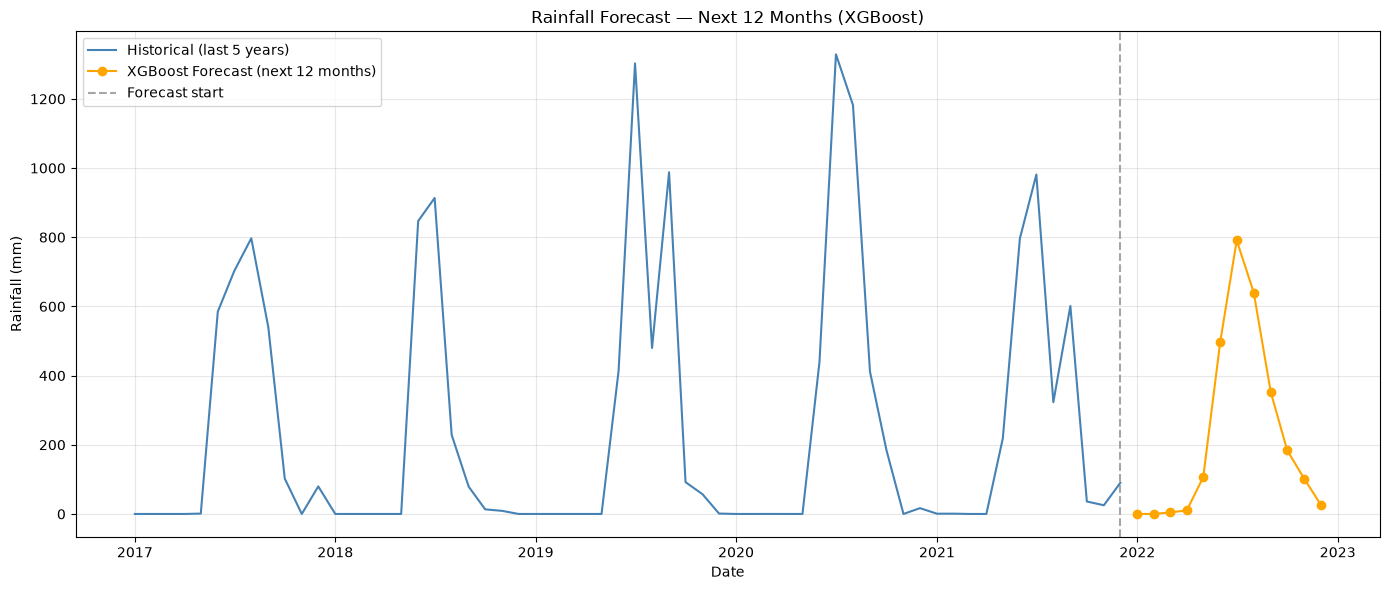

In [91]:
plt.figure(figsize=(14, 6))

# Show last 5 years of history for context
history_tail = df_melt['Rainfall'].tail(60)
plt.plot(history_tail.index, history_tail.values, label='Historical (last 5 years)', color='steelblue')

plt.plot(forecast_df['Date'], forecast_df['Predicted_Rainfall'],
         label='XGBoost Forecast (next 12 months)', color='orange', marker='o')

plt.axvline(x=df_melt.index[-1], color='gray', linestyle='--', alpha=0.7, label='Forecast start')
plt.title("Rainfall Forecast — Next 12 Months (XGBoost)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("forecast_plot.png", dpi=150, bbox_inches='tight')
print("Forecast plot saved to forecast_plot.png")
plt.show()

# 🔁 17. Task 2 — Walk-Forward Validation (Backtesting)

A single static 1901–2010 / 2011–2021 split is sensitive to the split boundary and does **not**
reflect production, where the model is periodically retrained and must forecast a full year ahead
**without** knowing the intermediate months.

**Protocol — expanding window, iterative 12-month-ahead.** For each forecast year *F* = 2011 … 2021:

1. Retrain XGBoost on **all** actual data up to December *F − 1*.
2. Recursively forecast the 12 months of *F*: predict January, append that prediction to the
   history and use it as `lag_1` for February, and so on. `lag_12` is always an actual value
   (same month, previous year), so the seasonal anchor stays real.
3. Record every (actual, predicted) pair.

Overall RMSE / MAE are computed across all 132 forecast months. This is stricter — and more honest —
than the static split, whose test rows used *actual* lags for every month (an implicit
1-step-ahead assumption).

In [92]:
from xgboost import XGBRegressor

# Rebuild the full monthly rainfall series (leak-free) directly from the raw df
_m = df.melt(id_vars=['Year'], var_name='Month', value_name='Rainfall')
_m['Month'] = _m['Month'].map(month_map)
_m['Date'] = pd.to_datetime(_m['Year'].astype(str) + '-' + _m['Month'].astype(str))
series = _m.sort_values('Date').set_index('Date')['Rainfall']

feature_cols = ['Month'] + [f'lag_{i}' for i in range(1, 13)]

def make_supervised(s):
    """Leak-free supervised frame: Month + lag_1..lag_12 (all past-only)."""
    f = pd.DataFrame({'Rainfall': s})
    f['Month'] = f.index.month
    for i in range(1, 13):
        f[f'lag_{i}'] = f['Rainfall'].shift(i)
    return f.dropna()

def new_xgb():
    return XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                        subsample=0.8, colsample_bytree=0.8, random_state=42)

records = []
for F in range(2011, 2022):                                   # forecast years 2011..2021
    train_end = f"{F-1}-12-31"
    train = make_supervised(series)
    train = train[train.index <= train_end]                   # expanding window
    model = new_xgb().fit(train[feature_cols], train['Rainfall'])

    history = series[series.index <= train_end].tolist()      # actuals up to Dec (F-1)
    for month in range(1, 13):
        row = {'Month': month, **{f'lag_{i}': history[-i] for i in range(1, 13)}}
        pred = max(float(model.predict(pd.DataFrame([row])[feature_cols])[0]), 0.0)
        history.append(pred)                                  # iterative feedback
        date = pd.Timestamp(year=F, month=month, day=1)
        records.append({'Date': date, 'y_true': float(series.get(date)), 'y_pred': pred})

wf_results = pd.DataFrame(records)
wf_rmse = np.sqrt(mean_squared_error(wf_results['y_true'], wf_results['y_pred']))
wf_mae  = mean_absolute_error(wf_results['y_true'], wf_results['y_pred'])

print("Per-year walk-forward RMSE / MAE:")
for F in range(2011, 2022):
    yr = wf_results[wf_results['Date'].dt.year == F]
    r = np.sqrt(mean_squared_error(yr.y_true, yr.y_pred))
    a = mean_absolute_error(yr.y_true, yr.y_pred)
    print(f"   {F}:  RMSE={r:7.2f}   MAE={a:7.2f}")

print(f"\nWALK-FORWARD OVERALL (2011-2021, {len(wf_results)} months):")
print(f"   RMSE = {wf_rmse:.2f}")
print(f"   MAE  = {wf_mae:.2f}")

Per-year walk-forward RMSE / MAE:
   2011:  RMSE= 226.52   MAE= 103.75
   2012:  RMSE= 130.39   MAE=  73.95
   2013:  RMSE= 231.49   MAE= 114.38
   2014:  RMSE= 263.61   MAE= 121.41
   2015:  RMSE= 233.28   MAE= 121.03
   2016:  RMSE= 145.94   MAE=  72.90
   2017:  RMSE= 141.72   MAE=  90.18
   2018:  RMSE= 180.57   MAE= 120.65
   2019:  RMSE= 282.70   MAE= 137.60
   2020:  RMSE= 243.89   MAE= 114.87
   2021:  RMSE= 199.18   MAE= 138.17

WALK-FORWARD OVERALL (2011-2021, 132 months):
   RMSE = 212.96
   MAE  = 109.90


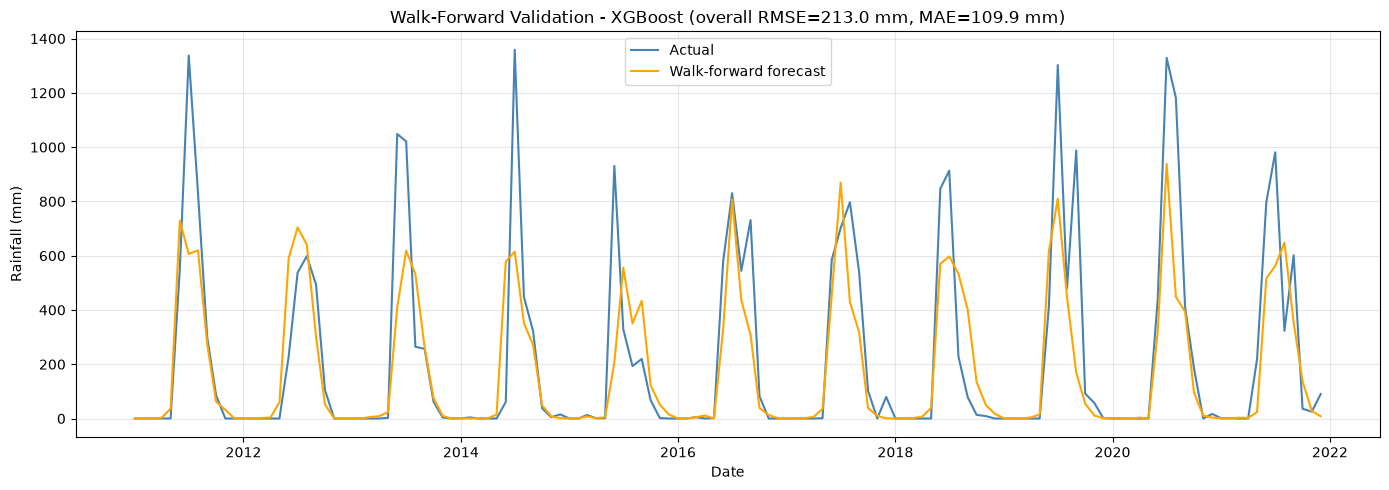

In [93]:
plt.figure(figsize=(14, 5))
plt.plot(wf_results['Date'], wf_results['y_true'], label='Actual', color='steelblue')
plt.plot(wf_results['Date'], wf_results['y_pred'], label='Walk-forward forecast', color='orange')
plt.title(f"Walk-Forward Validation - XGBoost (overall RMSE={wf_rmse:.1f} mm, MAE={wf_mae:.1f} mm)")
plt.xlabel("Date"); plt.ylabel("Rainfall (mm)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Result — backtested XGBoost: overall RMSE ≈ 212.96 mm, MAE ≈ 109.90 mm.**

This is *higher* than the static-split RMSE of 191.19 mm from Task 1, and that gap is the whole
point of backtesting. The static split let every test month see the *actual* previous month as
`lag_1` (an implicit 1-step-ahead assumption). Walk-forward forecasts a full year recursively —
predictions feed back as lags — so errors compound and the estimate reflects true production
performance.

Even under this stricter protocol the model still beats the seasonal-naive baseline
(RMSE 271.96 / MAE 136.03, quantified in Task 3), so XGBoost does add value. The margin is modest
and fold-to-fold performance is volatile (yearly RMSE ranges roughly 130–283 mm), which is expected
for a monsoon-dominated signal with high inter-annual variability.

# 📉 18. Task 3 — Seasonal-Naive Baseline & Statistical Comparison

A model is only useful if it beats the trivial alternative. The natural baseline for a strongly
seasonal series is the **seasonal-naive** forecast: *rainfall for month m of year Y = actual
rainfall for month m of year Y−1* — exactly `lag_12`. Because `lag_12` is always an observed value
at the forecast origin, the baseline needs no model and no recursion.

We evaluate it on the **identical** walk-forward window as Task 2 (2011–2021, 132 months) and then
ask the real question: **does XGBoost add *statistically significant* value, or is it just noise
around the baseline?** We answer with the Diebold–Mariano test (the standard test for comparing
forecast accuracy), backed up by a per-year win count and a conservative annual-level Wilcoxon
signed-rank test.

In [94]:
from scipy import stats

# Seasonal naive: forecast for month m of year Y = actual rainfall of month m of year Y-1
# (i.e. lag_12). lag_12 is always an actual value, so no recursion is needed.
wf_results['naive'] = series.shift(12).reindex(wf_results['Date']).values

y  = wf_results['y_true'].values
fx = wf_results['y_pred'].values          # walk-forward XGBoost
fn = wf_results['naive'].values           # seasonal naive

naive_rmse = np.sqrt(mean_squared_error(y, fn)); naive_mae = mean_absolute_error(y, fn)
xgb_rmse   = np.sqrt(mean_squared_error(y, fx)); xgb_mae   = mean_absolute_error(y, fx)

print(f"Walk-forward window 2011-2021 ({len(wf_results)} months)")
print(f"  Seasonal-naive :  RMSE = {naive_rmse:7.2f}   MAE = {naive_mae:7.2f}")
print(f"  XGBoost (WF)   :  RMSE = {xgb_rmse:7.2f}   MAE = {xgb_mae:7.2f}")
print(f"  Skill score (RMSE) = {1 - xgb_rmse/naive_rmse:.1%}    Skill score (MAE) = {1 - xgb_mae/naive_mae:.1%}")

Walk-forward window 2011-2021 (132 months)
  Seasonal-naive :  RMSE =  271.96   MAE =  136.03
  XGBoost (WF)   :  RMSE =  212.96   MAE =  109.90
  Skill score (RMSE) = 21.7%    Skill score (MAE) = 19.2%


In [95]:
def diebold_mariano(y, f1, f2, h=12, loss='mse'):
    """DM test with Harvey-Leybourne-Newbold small-sample correction.
       Negative statistic => f1 (XGBoost) is more accurate than f2 (naive)."""
    e1, e2 = y - f1, y - f2
    d = (e1**2 - e2**2) if loss == 'mse' else (np.abs(e1) - np.abs(e2))
    n = len(d); dbar = d.mean(); dc = d - dbar
    lrv = np.mean(dc**2)
    for k in range(1, h):                      # autocovariances up to h-1 (12-step forecast)
        lrv += 2 * np.mean(dc[k:] * dc[:-k])
    dm = dbar / np.sqrt(lrv / n)
    dm *= np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    return dm, stats.t.cdf(dm, df=n-1)         # one-sided p: H1 = XGBoost more accurate

for loss in ('mse', 'mae'):
    dm, p = diebold_mariano(y, fx, fn, h=12, loss=loss)
    verdict = "XGBoost significantly better" if p < 0.05 else "not significant"
    print(f"Diebold-Mariano ({loss.upper()} loss): stat = {dm:+.3f}   one-sided p = {p:.4f}   -> {verdict}")

wins = sum(np.sqrt(mean_squared_error(g.y_true, g.y_pred)) < np.sqrt(mean_squared_error(g.y_true, g.naive))
           for _, g in wf_results.groupby(wf_results['Date'].dt.year))
print(f"\nXGBoost beats seasonal-naive in {wins}/11 forecast years (RMSE).")

mae_x = [mean_absolute_error(g.y_true, g.y_pred) for _, g in wf_results.groupby(wf_results['Date'].dt.year)]
mae_n = [mean_absolute_error(g.y_true, g.naive)  for _, g in wf_results.groupby(wf_results['Date'].dt.year)]
_, p_wil = stats.wilcoxon(mae_x, mae_n, alternative='less')
print(f"Wilcoxon signed-rank on per-year MAE (11 yrs, conservative): p = {p_wil:.4f}")

Diebold-Mariano (MSE loss): stat = -2.758   one-sided p = 0.0033   -> XGBoost significantly better
Diebold-Mariano (MAE loss): stat = -2.299   one-sided p = 0.0115   -> XGBoost significantly better

XGBoost beats seasonal-naive in 9/11 forecast years (RMSE).
Wilcoxon signed-rank on per-year MAE (11 yrs, conservative): p = 0.0337


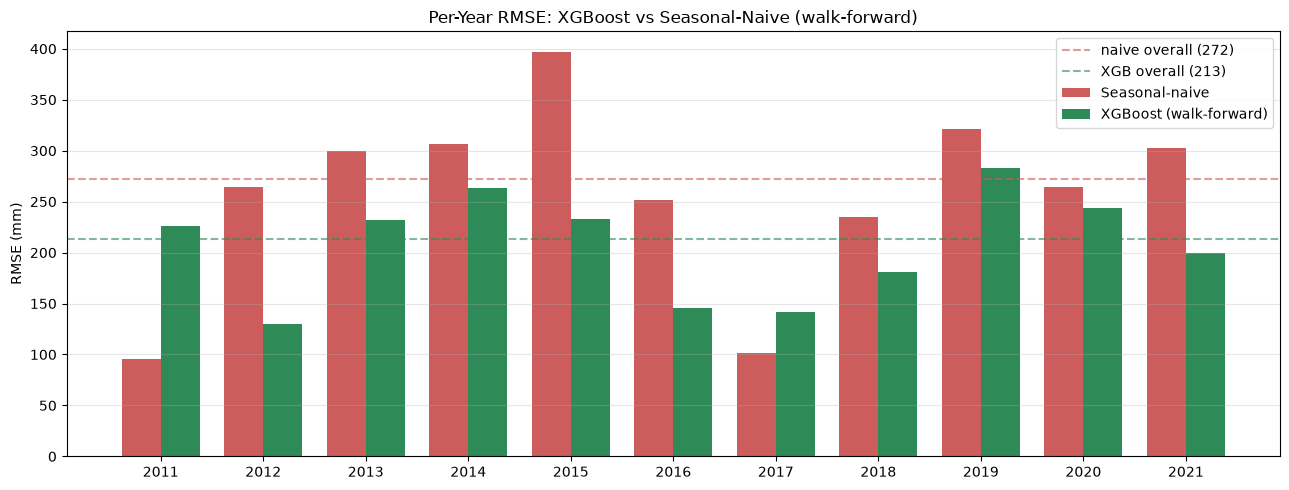

In [96]:
years = list(range(2011, 2022))
xgb_yr   = [np.sqrt(mean_squared_error(g.y_true, g.y_pred)) for _, g in wf_results.groupby(wf_results['Date'].dt.year)]
naive_yr = [np.sqrt(mean_squared_error(g.y_true, g.naive))  for _, g in wf_results.groupby(wf_results['Date'].dt.year)]

x = np.arange(len(years)); bw = 0.38
plt.figure(figsize=(13, 5))
plt.bar(x - bw/2, naive_yr, bw, label='Seasonal-naive', color='indianred')
plt.bar(x + bw/2, xgb_yr,   bw, label='XGBoost (walk-forward)', color='seagreen')
plt.axhline(naive_rmse, color='indianred', ls='--', alpha=0.6, label=f'naive overall ({naive_rmse:.0f})')
plt.axhline(xgb_rmse,   color='seagreen',  ls='--', alpha=0.6, label=f'XGB overall ({xgb_rmse:.0f})')
plt.xticks(x, years)
plt.ylabel('RMSE (mm)')
plt.title('Per-Year RMSE: XGBoost vs Seasonal-Naive (walk-forward)')
plt.legend(); plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Verdict — does the ML approach add statistical value?

**Yes.** On the identical 2011–2021 walk-forward window, XGBoost beats the seasonal-naive baseline on
every measure, and the improvement is statistically significant:

| | Seasonal-naive | XGBoost (walk-forward) | Improvement |
|---|---:|---:|---:|
| RMSE | 271.96 mm | **212.96 mm** | **21.7 %** |
| MAE  | 136.03 mm | **109.90 mm** | **19.2 %** |

- **Diebold–Mariano test** (HLN-corrected, h = 12): XGBoost is significantly more accurate under both
  squared-error loss (one-sided *p* = 0.0033) and absolute-error loss (*p* = 0.0115) — significant at
  the 1 % and 5 % levels respectively.
- XGBoost wins **9 of 11** forecast years on RMSE.
- A conservative annual-level **Wilcoxon signed-rank** test on the 11 near-independent yearly MAEs is
  also significant (*p* = 0.0337).

**But keep it in perspective.** The two years the baseline *won* (2011, 2017) were years whose rainfall
closely repeated the prior year — precisely where "assume this year = last year" is hard to beat. And
the honest walk-forward RMSE (~213 mm) is only modestly better than the naive floor and remains in the
same ballpark as SARIMA's static-split RMSE (186 mm, different protocol). **Recommendation:** deploy
XGBoost, but keep the seasonal-naive baseline in production monitoring — if the live model ever stops
beating `lag_12`, that is an immediate red flag.